In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages


In [13]:
path_output = 'simulation_output/'
simulation_name_krig = os.listdir(path_output)[0:-1:2]
simulation_name = os.listdir(path_output)[1::2]

In [14]:
simulation_name_krig

['realisation0_krige.pickle',
 'realisation10_krige.pickle',
 'realisation11_krige.pickle',
 'realisation12_krige.pickle',
 'realisation13_krige.pickle',
 'realisation14_krige.pickle',
 'realisation15_krige.pickle',
 'realisation16_krige.pickle',
 'realisation17_krige.pickle',
 'realisation18_krige.pickle',
 'realisation19_krige.pickle',
 'realisation1_krige.pickle',
 'realisation20_krige.pickle',
 'realisation21_krige.pickle',
 'realisation22_krige.pickle',
 'realisation2_krige.pickle']

In [15]:
exec(open('./functions/05_indice_Calculation.py').read())

In [16]:
%xmode plain

Exception reporting mode: Plain


In [28]:
dirName ='simu_reports'
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
except FileExistsError:
    print("Directory " , dirName ,  " already exists")




all_output = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
for name in simulation_name:
    pp = PdfPages(dirName +'/' + name +'.pdf')
    it = 0
    with open('simulation_output/'+name,'rb') as file:
        real_alt, simus_sets = pickle.load(file)
    
    with open('simulation_output/'+name[0:-11]+'krige.pickle','rb') as file:
         real_k, krieg_sets = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(real_alt,simus,'mps')
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
    pro = indice_calculation(real_k,krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + pro)
    
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd'])


Directory  simu_reports  already exists


C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:69: RuntimeWarning: invalid value encountered in true_divide
C:\Users\nevena\AppData\Local\Continuum\anaconda3\envs\Pyclass36\lib\site-packages\ipykernel_launcher.py:36: RuntimeWarning: invalid value encountered in true_divide


In [29]:
results_frame
#[results_frame['Type']=='KRIG']

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd
0,realisation0_simu.pickle,MPS1,2.133423,4.865045,1.817515,"[[2278.743773811246, 2278.561350730613, 2278.4...","[[0.27847034138752164, 0.3638583702837888, 0.2..."
1,realisation0_simu.pickle,MPS2,-2318.323417,2318.323417,130.833281,"[[-47.896734116380784, -48.38033567850054, -48...","[[210.04538077319586, 209.9140652353894, 210.0..."
2,realisation0_simu.pickle,GRF,2.594685,3.199300,4.253005,"[[2279.065185546875, 2279.006103515625, 2278.9...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
3,realisation0_simu.pickle,KRIG,2.631333,2.819549,2.210591,"[[2279.065185546875, 2279.006103515625, 2278.9...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
4,realisation10_simu.pickle,MPS1,5.550701,6.416866,3.656176,"[[2248.8771921863386, 2247.0914009586118, 2245...","[[0.484087885929903, 0.6314603793787692, 0.628..."
...,...,...,...,...,...,...,...
59,realisation22_simu.pickle,KRIG,2.156061,2.268554,1.560899,"[[2500.1083984375, 2500.139892578125, 2500.178...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
60,realisation2_simu.pickle,MPS1,-2.581885,4.446026,1.882951,"[[2143.528155565022, 2143.5978347506216, 2143....","[[0.3345701043736411, 0.3751814194272145, 0.27..."
61,realisation2_simu.pickle,MPS2,-2197.248906,2197.248906,117.616200,"[[-48.54443491021823, -49.0357935524613, -49.6...","[[210.03734783841887, 209.9029271946389, 210.0..."
62,realisation2_simu.pickle,GRF,2.078612,2.654025,3.183432,"[[2143.971923828125, 2144.14794921875, 2144.36...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


In [19]:
len(simus_sets[0])

10

ValueError: num must be 1 <= num <= 2, not 3

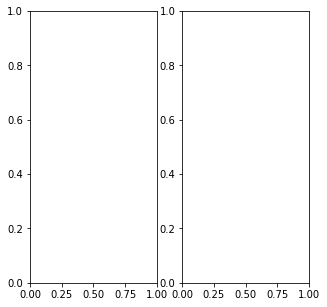

In [20]:
plt.subplots(1,2,figsize=(5,5))
plt.subplot(1,2,3)

In [21]:
real_alt.shape

(100, 100)

TypeError: Invalid shape () for image data

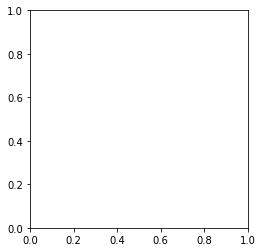

In [22]:
plt.imshow(all_output[3][3])

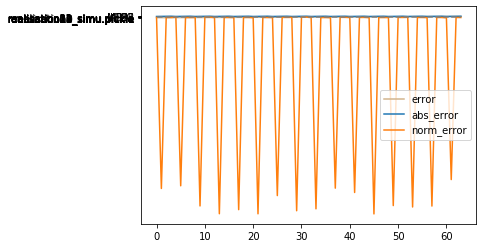

In [23]:
pts_0 = [elt[0] for elt in all_output]
pts_1 = [elt[1] for elt in all_output]
pts_2 = [elt[2] for elt in all_output]


plt.plot(pts_0,color='tan')
plt.plot(pts_1)
plt.plot(pts_2)
plt.legend(['error','abs_error','norm_error'])
plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')
#plt.plot(pts[2])
#plt.plot(pts[0])

Text(0, 0.5, 'Error [m]')

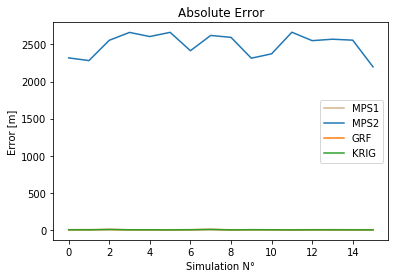

In [24]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


Text(0, 0.5, 'Error [m]')

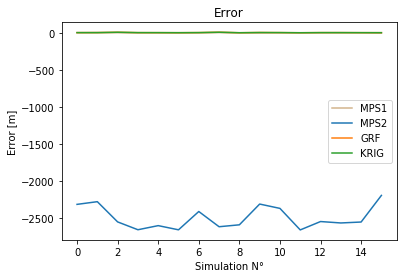

In [25]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

Text(0, 0.5, 'Error [m]')

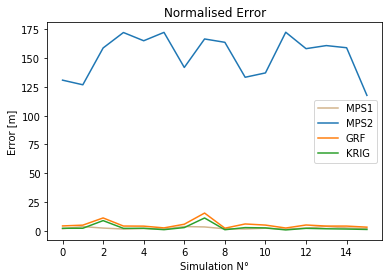

In [26]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')

In [ ]:
a = results_frame[results_frame['Type']=='MPS1'].Abs_error.values

In [11]:
name[0:-11]

'realisation10_'